# XAI-project — Utilidad operacional (triage) de los scores

**Course:** INF-473 Explainable AI · UTFSM · Prof. Raquel Pezoa Rivera
**Authors:** Eduardo Morales · Octavia Jara · Benjamín Reyes

**Notebook:** `modeling/05_operational_triage` — evalúa el modelo como herramienta de priorización: recall/lift/precisión por presupuesto de inspección, en los modos L1→L1, L2→L2 y L1→L2 (proxy). Guarda `latex/images/operational_triage.png` y muestra la figura inline.

> Requiere `data/processed/conaf_enriched_2012_2018.parquet`. Ver [`README.md`](../README.md).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from IPython.display import display

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import BASE_DIR, DATA_PROCESSED  # noqa: E402
from src.modeling_features import (  # noqa: E402
    FEATURE_COLS,
    MEGAFIRE_HA_THRESHOLD,
    N_SPLITS,
    RANDOM_STATE,
    STUDY_REGIONS,
    XGB_PARAMS,
)

DATA = DATA_PROCESSED / "conaf_enriched_2012_2018.parquet"
OUT_PNG = BASE_DIR / "latex" / "images" / "operational_triage.png"

N_REPEATS = 20
BUDGETS = [0.01, 0.02, 0.05, 0.10, 0.20]  # fracción de ignitiones priorizadas


def load():
    """Carga 2012-2018 (4 regiones) y prepara features y ambas etiquetas.

    Returns:
        Tupla ``(X, y_l1, y_l2)`` con la matriz de features y las dos etiquetas
        binarias, restringidas a las regiones de estudio y filas modelables.
    """
    df = pd.read_parquet(DATA)
    df = df[df["region"].astype(str).isin(STUDY_REGIONS)].copy()
    ts = pd.to_datetime(df["fecha_hora_inicio"], errors="coerce")
    df["month"], df["hour"], df["day_of_year"] = ts.dt.month, ts.dt.hour, ts.dt.dayofyear
    for c in ["region", "provincia", "comuna"]:
        df[c] = pd.Categorical(df[c]).codes
    cols = [c for c in FEATURE_COLS if c in df.columns]
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    cols = [c for c in cols if not df[c].isna().all()]
    df["label_l1"] = (df["superficie_quemada_total_ha"] >= MEGAFIRE_HA_THRESHOLD).astype(int)
    df = df.dropna(subset=["superficie_quemada_total_ha", "label_l2"] + cols).reset_index(drop=True)
    return df[cols].values, df["label_l1"].values.astype(int), df["label_l2"].astype(int).values


def repeated_oof(X, y):
    """Probabilidad OOF promediada sobre ``N_REPEATS`` particiones estratificadas."""
    oof = np.zeros(len(y))
    for rep in range(N_REPEATS):
        spw = (len(y) - y.sum()) / max(y.sum(), 1)
        m = xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw)
        skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE + rep)
        oof += cross_val_predict(m, X, y, cv=skf, method="predict_proba", n_jobs=1)[:, 1]
    return oof / N_REPEATS


def triage_table(scores, y, label):
    """Tabla de operación: por cada presupuesto, recall, lift, precisión y costo.

    Args:
        scores: Riesgo OOF por evento (mayor = más prioritario).
        y: Etiqueta binaria objetivo del triage.
        label: Texto descriptivo del modo (para el encabezado).

    Returns:
        DataFrame con una fila por presupuesto.
    """
    n, P = len(y), int(y.sum())
    order = np.argsort(-scores)
    rows = []
    for k in BUDGETS:
        n_flag = max(1, int(round(k * n)))
        tp = int(y[order[:n_flag]].sum())
        recall = tp / P
        rows.append(dict(
            budget=f"{k*100:.0f}%", n_flag=n_flag, tp=f"{tp}/{P}",
            recall=round(recall, 2), lift=round(recall / k, 1),
            precision=round(tp / n_flag, 3), fp_per_tp=round((n_flag - tp) / tp, 1) if tp else np.inf,
        ))
    df = pd.DataFrame(rows)
    print(f"\n=== Triage {label} (P={P} positivos de {n}) ===")
    print(df.to_string(index=False))
    return df


def gains(scores, y):
    """Curva de ganancia acumulada: (fracción priorizada, fracción capturada)."""
    order = np.argsort(-scores)
    frac_pop = np.arange(1, len(y) + 1) / len(y)
    frac_cap = np.cumsum(y[order]) / max(y.sum(), 1)
    return frac_pop, frac_cap

## Carga + scores OOF (L1, L2)

In [2]:
print(f"Cargando {DATA.name} (4 regiones)...")
X, y_l1, y_l2 = load()
print(f"Filas: {len(y_l1)} | L1: {y_l1.sum()} | L2: {y_l2.sum()}")
print("OOF L1..."); oof_l1 = repeated_oof(X, y_l1)
print("OOF L2..."); oof_l2 = repeated_oof(X, y_l2)

Cargando conaf_enriched_2012_2018.parquet (4 regiones)...
Filas: 30511 | L1: 76 | L2: 11
OOF L1...


OOF L2...


## Tablas de triage (3 modos)

In [3]:
triage_table(oof_l1, y_l1, "L1->L1 (area model triages area mega-fires)")
triage_table(oof_l2, y_l2, "L2->L2 (intensity model triages EWE)")
triage_table(oof_l1, y_l2, "L1->L2 (area model triages intensity — proxy)")


=== Triage L1->L1 (area model triages area mega-fires) (P=76 positivos de 30511) ===
budget  n_flag    tp  recall  lift  precision  fp_per_tp
    1%     305 30/76    0.39  39.5      0.098        9.2
    2%     610 34/76    0.45  22.4      0.056       16.9
    5%    1526 51/76    0.67  13.4      0.033       28.9
   10%    3051 61/76    0.80   8.0      0.020       49.0
   20%    6102 69/76    0.91   4.5      0.011       87.4

=== Triage L2->L2 (intensity model triages EWE) (P=11 positivos de 30511) ===
budget  n_flag   tp  recall  lift  precision  fp_per_tp
    1%     305 5/11    0.45  45.5      0.016       60.0
    2%     610 6/11    0.55  27.3      0.010      100.7
    5%    1526 7/11    0.64  12.7      0.005      217.0
   10%    3051 9/11    0.82   8.2      0.003      338.0
   20%    6102 9/11    0.82   4.1      0.001      677.0

=== Triage L1->L2 (area model triages intensity — proxy) (P=11 positivos de 30511) ===
budget  n_flag   tp  recall  lift  precision  fp_per_tp
    1%     30

,budget,n_flag,tp,recall,lift,precision,fp_per_tp
0,1%,305,6/11,0.55,54.5,0.020,49.8
1,2%,610,6/11,0.55,27.3,0.010,100.7
2,5%,1526,6/11,0.55,10.9,0.004,253.3
3,10%,3051,7/11,0.64,6.4,0.002,434.9
4,20%,6102,8/11,0.73,3.6,0.001,761.8


## Figura — guardada en `latex/images/` + mostrada inline

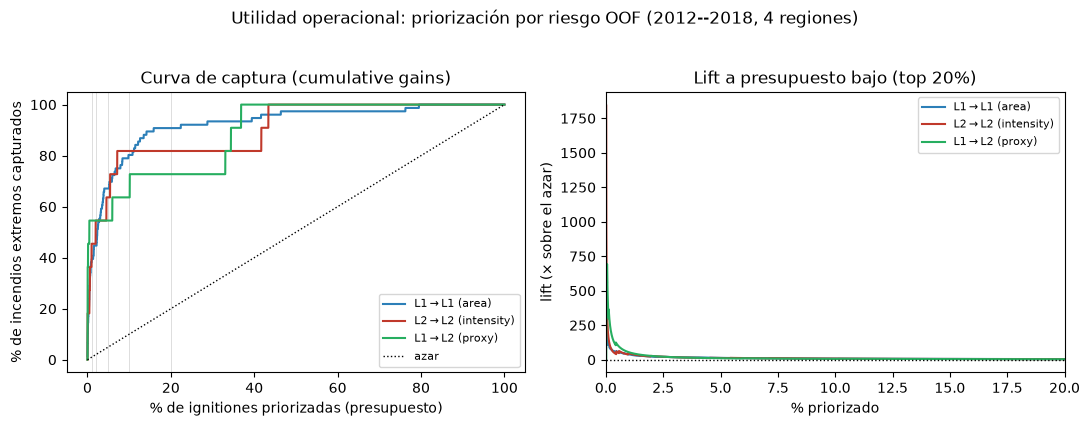


✅ Figura: /home/imorales/Desktop/XAI/XAI-project/latex/images/operational_triage.png


In [4]:
fig, (axg, axl) = plt.subplots(1, 2, figsize=(11, 4.3))
for scores, y, lab, c in [(oof_l1, y_l1, "L1$\\to$L1 (area)", "#2c7fb8"),
                          (oof_l2, y_l2, "L2$\\to$L2 (intensity)", "#c0392b"),
                          (oof_l1, y_l2, "L1$\\to$L2 (proxy)", "#27ae60")]:
    fp, fc = gains(scores, y)
    axg.plot(fp * 100, fc * 100, label=lab, color=c)
    # lift = recall / fraccion priorizada
    lift = np.divide(fc, fp, out=np.zeros_like(fc), where=fp > 0)
    axl.plot(fp * 100, lift, color=c, label=lab)
axg.plot([0, 100], [0, 100], "k:", lw=1, label="azar")
for k in BUDGETS:
    axg.axvline(k * 100, color="#ddd", lw=0.7, zorder=0)
axg.set_xlabel("% de ignitiones priorizadas (presupuesto)")
axg.set_ylabel("% de incendios extremos capturados")
axg.set_title("Curva de captura (cumulative gains)")
axg.legend(fontsize=8, loc="lower right")
axl.set_xlim(0, 20); axl.axhline(1, color="k", ls=":", lw=1)
axl.set_xlabel("% priorizado"); axl.set_ylabel("lift (× sobre el azar)")
axl.set_title("Lift a presupuesto bajo (top 20%)")
axl.legend(fontsize=8)
fig.suptitle("Utilidad operacional: priorización por riesgo OOF (2012--2018, 4 regiones)")
fig.tight_layout(rect=(0, 0, 1, 0.95))
OUT_PNG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_PNG, dpi=130, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"\n✅ Figura: {OUT_PNG}")